  K= 2  silhouette=0.6072
  K= 3  silhouette=0.7819
  K= 4  silhouette=0.8336
  K= 5  silhouette=0.7005
  K= 6  silhouette=0.5635
  K= 7  silhouette=0.4506
  K= 8  silhouette=0.3489
  K= 9  silhouette=0.3470
  K=10  silhouette=0.3509

Best K = 4  (silhouette = 0.8336)


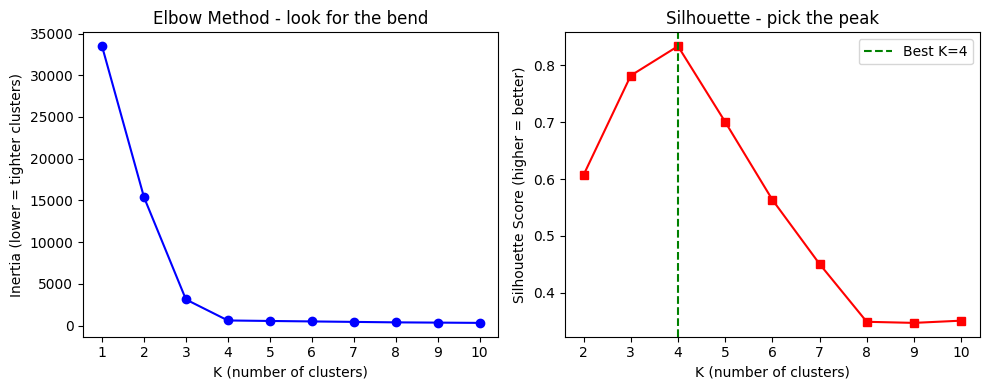

In [3]:
# ── CELL: fully self-contained, paste & run in Colab ─────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create demo data (replace with your own X if you have it)
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

# ── TECHNIQUE 1: Elbow Method ────────────────────────────────────
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertias, 'bo-')
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method - look for the bend')
plt.xticks(range(1, 11))

# ── TECHNIQUE 2: Silhouette Score ───────────────────────────────
sil_scores = []
for k in range(2, 11):           # k=1 is invalid for silhouette!
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    score  = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"  K={k:2d}  silhouette={score:.4f}")

# Find best K
best_idx   = sil_scores.index(max(sil_scores))  # position of highest score
best_k     = range(2, 11)[best_idx]              # the actual K value
best_score = max(sil_scores)

print(f"\nBest K = {best_k}  (silhouette = {best_score:.4f})")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores, 'rs-')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K (number of clusters)')
plt.ylabel('Silhouette Score (higher = better)')
plt.title('Silhouette - pick the peak')
plt.xticks(range(2, 11))
plt.legend()

plt.tight_layout()
plt.show()

# Memory Trick (as a comment, not code - so no syntax error!)
# S-I-L = Score, Index, Lookup
# sil_scores            = collect Scores for each K
# .index(max(...))      = find Index of the best score
# range(2,11)[index]    = Lookup the actual K at that index